<font color="green"> <b><h1>Prueba Módulo 5: Machine Learning<h1></b> </font>

<font color="green"> **<h1>Ejercicio 1</h1>** </font>

<p> Describe con detenimiento el problema de negocio que se desea resolver, y cómo se
va a hacer esto. Indica la metodología, tareas a realizar, variable objetivo a predecir,
etc.</p>

<font color="blue"> **<h2>Análisis del caso</h2>** </font>

* **Problema de Negocio:** Una agencia de viajes de avión desea: "Desarrollar un modelo predictivo capaz de estimar el precio de un boleto de avión
basándonos en diversas características del vuelo", según lo citado en el caso. Para esto se puede desarrollar una herramienta, por ejemplo, una aplicación móvil, para recomendar las mejores opciones de vuelos a sus clientes. El principal problema radica en la alta _volatilidad_ de las tarifas.

* **Plan de Acción:** Se desarrollarán, evaluarán y compararán modelos de Machine Learning basados en aprendizaje supervisado (Regresión lineal simple, regresión multilineal, Regresión con regularización, Árboles de decisión regresivos y Random Forest) para elegir el más adecuado de acuerdo a sus métricas de error. El plan consiste en analizar los datos históricos de características de los vuelos provistos, limpiar y transformar estas variables, y entrenar los algoritmos predictivos capaces de inferir el precio de un vuelo nuevo basándose en sus atributos (ruta, escalas, fechas, etc.).

* **Metodología:** Se utilizará la metodología _CRISP-DM_ (Cross-Industry Standard Process for Data Mining). Este marco de trabajo garantiza un enfoque estructurado, iterativo incremental y orientado a los objetivos comerciales del proyecto.

* **Tareas a Realizar (basadas en _CRISP-DM_):**

  1. **Business Understanding (Comprensión del negocio):** Establecer que el objetivo principal es minimizar el margen de error estadístico en la predicción de la tarifa aérea.
  2. **Data Understanding (Comprensión de los datos):** Cargar los archivos .xlsx, explorar la distribución de las tarifas, conocer correlaciones entre los datos e identificar anomalías, problemas de escala en los datos o valores atípicos (outliers) extremos entre los conjuntos de datos.
  3. **Data Preparation (Preparación de los datos):** Limpiar valores nulos. Extraer componentes numéricos de variables temporales (Date_of_Journey, Dep_Time, Duration). Codificar variables categóricas nominales (Airline, Source, Destination) y ordinales (Total_Stops).
  4. **Modeling (Modelado):** Seleccionar, entrenar y utilizar herramientas automatizadas como GridSearch para ajustar hiperparámetros de los algoritmos de regresión mencionados en el plan de acción.
  5. **Evaluation (Evaluación):** Cuantificar el desempeño del modelo utilizando métricas de error pertinentes (como MSE, RMSE, o MAE) y el coeficiente de determinación ($R^2$) para validar su viabilidad antes del despliegue en la aplicación.
  6. **Deploy (Despliegue):** Esta es la etapa donde el modelo se exporta para aplicarse en la herramienta (ej App) que va a utilizar la empresa para que los clientes tengan una estimación del precio de los vuelos en diferentes aerolíneas.
* **Variable Objetivo (target):**
    **Price:** Variable numérica continua que representa la tarifa final del vuelo a predecir.

* **Variables Explicativas (Features):** Las características independientes extraídas de la estructura del dataset que influyen en la fluctuación de la variable objetivo: **Airline (Aerolínea)**, **Date_of_Journey (Fecha del viaje)**, **Source (Ciudad de origen)**, **Destination (Ciudad de destino)**, **Route (Ruta específica)**, **Dep_Time (Hora de salida)**, **Arrival_Time (Hora de llegada)**, **Duration (Duración total del vuelo)**, **Total_Stops (Número de escalas)**, **Additional_Info (Información adicional del servicio)**. Algunas de estas variables estarán más correlacionadas con la variable objetivo que otras, y algunas no proporcionarán información relevante para el análisis. Todo eso se descubrirá a medida que se avanza y se itera el modelo CRISP-DM.

<font color="green"> **<h1>Ejercicio 2</h1>** </font>

<p>Carga los dataset entregados y genera un reporte de calidad de los mismos. Indica
qué estrategias se van a utilizar para aquellos puntos encontrados (Indicar nulos,
outliers, valores perdidos, que se hará con esto, etc.)</p>

In [28]:
import pandas as pd
from IPython.display import display

def cargar_y_analizar_datos(ruta_archivo):
    """
    Carga un archivo Excel y realiza un análisis de calidad inicial de los datos.
    """
    try:
        # 1. Carga de datos
        print("-"*80)
        print(f"INICIANDO ANÁLISIS DE: {ruta_archivo}")
        print("-"*80)
        df = pd.read_excel(ruta_archivo)
        print("Archivo cargado exitosamente.")
        print("\n")
        print("="*80)

        # 2. Análisis exploratorio conceptual
        print("\t1. Primeras 5 filas (Vista previa):")
        display(df.head())

        print("="*80)
        print("\n\t2. Información General (Tipos de datos y memoria):")
        df.info()

        print("="*80)
        print("\n\t3. Estadísticas Descriptivas (Variables Numéricas):")
        display(df.describe())
        
        print("="*80)
        print("\n\t4. Estadísticas Descriptivas (Variables Categóricas):")
        # include='O' selecciona las columnas de tipo Object (texto/categóricas)
        display(df.describe(include=['O']))

        print("="*80)
        print("\n\t5. Conteo de Valores Nulos por columna:")
        nulos = df.isnull().sum()
        print(nulos[nulos > 0] if nulos.sum() > 0 else "No se encontraron valores nulos.")

        print("="*80)
        print(f"\n\t6. Dimensiones del Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
        print("\n\n")
        
        return df

    except FileNotFoundError:
        print(f"ERROR: No se encontró el archivo '{ruta_archivo}'. Verifica que esté en la misma carpeta que este notebook.")
    except Exception as e:
        print(f"ERROR INESPERADO al procesar '{ruta_archivo}': {e}")

In [29]:
# EJECUCIÓN

# Nombres de los archivos
business = "business.xlsx"
economy = "economy.xlsx"

# Almacenamos los DataFrames en variables para usarlos en el siguiente paso
df_business = cargar_y_analizar_datos(business)
df_economy = cargar_y_analizar_datos(economy)

--------------------------------------------------------------------------------
INICIANDO ANÁLISIS DE: business.xlsx
--------------------------------------------------------------------------------
Archivo cargado exitosamente.


	1. Primeras 5 filas (Vista previa):


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690



	2. Información General (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 7.8+ MB

	3. Estadísticas Descriptivas (Variables Numéricas):


,date,num_code
count,93487,93487.000000
mean,2022-03-07 17:48:16.458331136,780.056147
min,2022-02-11 00:00:00,401.000000
25%,2022-02-24 00:00:00,706.000000
50%,2022-03-08 00:00:00,820.000000
75%,2022-03-20 00:00:00,874.000000
max,2022-03-31 00:00:00,996.000000
std,NaN,147.616038



	4. Estadísticas Descriptivas (Variables Categóricas):


...


	2. Información General (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        206774 non-null  datetime64[ns]
 1   airline     206774 non-null  object        
 2   ch_code     206774 non-null  object        
 3   num_code    206774 non-null  int64         
 4   dep_time    206774 non-null  object        
 5   from        206774 non-null  object        
 6   time_taken  206774 non-null  object        
 7   stop        206774 non-null  object        
 8   arr_time    206774 non-null  object        
 9   to          206774 non-null  object        
 10  price       206774 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 17.4+ MB

	3. Estadísticas Descriptivas (Variables Numéricas):


,date,num_code,price
count,206774,206774.000000,206774.000000
mean,2022-03-08 02:57:25.083037440,1706.096714,6571.190701
min,2022-02-11 00:00:00,101.000000,1105.000000
25%,2022-02-25 00:00:00,588.000000,4173.000000
50%,2022-03-08 00:00:00,818.000000,5772.000000
75%,2022-03-20 00:00:00,960.000000,7746.000000
max,2022-03-31 00:00:00,9991.000000,42349.000000
std,NaN,2320.463721,3743.442838



	4. Estadísticas Descriptivas (Variables Categóricas):


,airline,ch_code,dep_time,from,time_taken,stop,arr_time,to
count,206774,206774,206774,206774,206774,206774,206774,206774
unique,8,8,251,6,483,37,266,6
top,Vistara,UK,07:00:00,Delhi,02h 10m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,19:55:00,Delhi
freq,67270,67270,4955,43029,3081,162114,5002,40654



	5. Conteo de Valores Nulos por columna:
No se encontraron valores nulos.

	6. Dimensiones del Dataset: 206774 filas x 11 columnas





<font color="blue"> **<h2>Análisis de calidad inicial de los datos<h2>**</font>

<p>En un primer análisis encontramos informaicón valiosa que nos permite diagnosticar la calidad inicial de los datos y proponer un plan de limpieza inicial:</p>

**<h3>1. Diagnóstico de Calidad de Datos</h3>**

<p>Tras cargar y auditar los conjuntos de datos business.xlsx (93,487 registros) y economy.xlsx (206,774 registros), se observan las siguientes condiciones:</p>

* **Valores Nulos:** Afortunadamente, no existen valores nulos en ninguna de las 11 columnas de ambos datasets, lo cual nos ahorra la fase de imputación.

* **Tipos de Datos y Casting:** La mayoría de las variables fueron leídas como tipo object (texto). La variable objetivo price en el dataset business aparece como object y debe ser obligatoriamente casteada a numérico. Las variables temporales (dep_time, arr_time) y de duración (time_taken) también son de tipo object y requerirán extracción numérica.

* **Redundancia y Variables Irrelevantes:** Se identifican variables que actúan como identificadores de vuelo (ch_code, num_code) y geográficos redundantes/estáticos (from, to), las cuales no aportan valor estadístico al modelo predictivo y podrían causar sobreajuste, por lo que serán eliminadas.

* **Detección de Outliers:** Al estar la mayoría de las columnas como texto, no se pudo realizar un análisis de cuartiles automático. Una vez se casteen a formato numérico (especialmente el price), se ejecutará un análisis descriptivo para comparar la distancia entre el mínimo y el Q1, y entre el Q3 y el máximo, buscando si existen dispersiones severas que indiquen la presencia de valores atípicos.

**<h3>2. Plan de Limpieza y Transformación</h3>**

* **Unión de Datasets:** Para entrenar un modelo global, se agregará una columna indicadora de "Clase" y se concatenarán ambos datasets.

* **Eliminación:** Se descartarán ch_code, num_code, from, y to.

* **Casting:** Se forzará la variable price a tipo numérico, entre otros casteos a sus tipos de dato adecuados.

* **Evaluación de Outliers:** Se revisarán las estadísticas de variables numéricas luego del casteo.

In [30]:
import numpy as np

def limpiar_y_analizar_outliers(df_bus, df_eco):
    """
    Limpia, unifica, realiza conversiones (casting) y ejecuta un 
    análisis estadístico para detección de outliers en variables numéricas.
    """
    print("INICIANDO PREPROCESAMIENTO Y ANÁLISIS DE OUTLIERS...")
    
    # 1. Marcar el origen de los datos antes de unir (Feature Engineering Básico)
    df_bus = df_bus.copy()
    df_eco = df_eco.copy()
    df_bus['Class'] = 'Business'
    df_eco['Class'] = 'Economy'
    
    # 2. Unificar datasets
    df_full = pd.concat([df_bus, df_eco], ignore_index=True)
    print(f"Datasets unificados. Total registros: {len(df_full)}")
    
    # 3. Eliminar columnas que no aportan estadísticamente
    columnas_a_eliminar = ['ch_code', 'num_code', 'from', 'to']
    df_full.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')
    print(f"Columnas eliminadas: {columnas_a_eliminar}")
    
    # 4. Castear 'price' a numérico
    if df_full['price'].dtype == 'object':
        df_full['price'] = pd.to_numeric(df_full['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    
    # Nos aseguramos de eliminar los datos de una entrada si es que su casteo sale mal
    nulos_precio = df_full['price'].isnull().sum()
    if nulos_precio > 0:
         print(f"Atención: {nulos_precio} registros de precio se perdieron. Se proceden a eliminar.")
         df_full.dropna(subset=['price'], inplace=True)
    print("Variable 'price' casteada correctamente a numérico.")

    # 5 Castear 'time_taken' a numérico (Duración total en minutos)
    if 'time_taken' in df_full.columns:
        # Extraer números antes de 'h' y 'm' usando expresiones regulares
        horas = df_full['time_taken'].str.extract(r'(\d+(?:\.\d+)?)\s*h')[0].fillna(0).astype(float)
        minutos = df_full['time_taken'].str.extract(r'(\d+(?:\.\d+)?)\s*m')[0].fillna(0).astype(float)
        
        # Crear nueva columna numérica
        df_full['duration_mins'] = horas * 60 + minutos
        df_full.drop(columns=['time_taken'], inplace=True)
        print("Variable 'time_taken' transformada exitosamente a 'duration_mins' (numérica).")
    
    # 6. Análisis Descriptivo para Detección de Outliers en variables numéricas
    variables_numericas = df_full.select_dtypes(include=[np.number]).columns.tolist()
    
    print("\n" + "-"*70)
    print("ANÁLISIS ESTADÍSTICO DE DISPERSIÓN (Detección de Outliers)")
    print("-"*70)
    
    clases = df_full['Class'].unique()
    
    for var in variables_numericas:
        print(f"\n" + "*"*45)
        print(f"ANALIZANDO VARIABLE: {var.upper()}")
        print("*"*45)
        
        for c in clases:
            data_clase = df_full[df_full['Class'] == c][var].dropna()
            stats = data_clase.describe()
            
            q1 = stats['25%']
            q3 = stats['75%']
            
            # Usamos el método IQR para calcular límites teóricos
            iqr = q3 - q1
            limite_sup_iqr = q3 + 1.5 * iqr
            limite_inf_iqr = q1 - 1.5 * iqr
            
            print(f"\n--- Segmento: {c.upper()} ---")
            display(stats.to_frame().T)
            
            # Contar outliers
            outliers_inf = data_clase[data_clase < limite_inf_iqr].count()
            outliers_sup = data_clase[data_clase > limite_sup_iqr].count()
            
            if outliers_sup > 0 or outliers_inf > 0:
                 print(f"ALERTA: Se detectaron {outliers_inf} atípicos en la cola inferior y {outliers_sup} en la cola superior.")
                 print(f"(Límites estadísticos IQR -> Inf: {limite_inf_iqr:.2f} | Sup: {limite_sup_iqr:.2f})")
            else:
                 print("Distribución balanceada. Sin indicios de outliers extremos (método IQR).")

    return df_full

In [32]:
# EJECUCIÓN

df_limpio = limpiar_y_analizar_outliers(df_business, df_economy)

INICIANDO PREPROCESAMIENTO Y ANÁLISIS DE OUTLIERS...
Datasets unificados. Total registros: 300261
Columnas eliminadas: ['ch_code', 'num_code', 'from', 'to']
Variable 'price' casteada correctamente a numérico.
Variable 'time_taken' transformada exitosamente a 'duration_mins' (numérica).

----------------------------------------------------------------------
ANÁLISIS ESTADÍSTICO DE DISPERSIÓN (Detección de Outliers)
----------------------------------------------------------------------

*********************************************
ANALIZANDO VARIABLE: PRICE
*********************************************

--- Segmento: BUSINESS ---


,count,mean,std,min,25%,50%,75%,max
price,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0


ALERTA: Se detectaron 2373 atípicos en la cola inferior y 1277 en la cola superior.
(Límites estadísticos IQR -> Inf: 22368.50 | Sup: 83212.50)

--- Segmento: ECONOMY ---


,count,mean,std,min,25%,50%,75%,max
price,206774.0,6571.190701,3743.442838,1105.0,4173.0,5772.0,7746.0,42349.0


ALERTA: Se detectaron 0 atípicos en la cola inferior y 13750 en la cola superior.
(Límites estadísticos IQR -> Inf: -1186.50 | Sup: 13105.50)

*********************************************
ANALIZANDO VARIABLE: DURATION_MINS
*********************************************

--- Segmento: BUSINESS ---


,count,mean,std,min,25%,50%,75%,max
duration_mins,93487.0,822.253468,411.148768,60.0,530.0,785.0,1070.0,2865.0


ALERTA: Se detectaron 0 atípicos en la cola inferior y 90 en la cola superior.
(Límites estadísticos IQR -> Inf: -280.00 | Sup: 1880.00)

--- Segmento: ECONOMY ---


,count,mean,std,min,25%,50%,75%,max
duration_mins,206774.0,692.741594,434.53376,50.0,375.0,610.0,915.0,2990.0


ALERTA: Se detectaron 0 atípicos en la cola inferior y 2652 en la cola superior.
(Límites estadísticos IQR -> Inf: -435.00 | Sup: 1725.00)


<font color="orange"> **<h3>Resultados del Preprocesamiento y Detección de Outliers</h3>** </font>

<p>Tras la ejecución del pipeline de limpieza y transformación en los registros unificados, se lograron los siguientes hitos de preparación:</p>

* **Limpieza Estructural:** Se eliminaron las variables redundantes y se transformó con éxito el formato de texto de la duración a una variable numérica continua (duration_mins).

* **Segmentación**: La incorporación de la variable Class ahora permite un análisis bivariado que revela comportamientos estadísticos radicalmente distintos entre ambos segmentos.

<p>A continuación, se detalla el diagnóstico de dispersión (por método IQR):</p>

**<h4>Análisis de la Variable Price (Tarifa)</h4>**

* **Clase Business:** Presenta una media altísima (52,540) en comparación con Economy. Se detectaron 2,373 outliers inferiores (vuelos por debajo de 22,368, lo cual podría indicar principalmente ofertas extremas) y 1,277 outliers superiores (vuelos de lujo ultra caros que superan los 83,212).

* **Clase Economy:** Presenta un comportamiento de asimetría positiva, es decir, no existen outliers inferiores, pero se detectaron 13,750 outliers superiores (vuelos por encima de 13,105). Esta parece ser una característica natural de la industria de vuelos aéreos, donde los vuelos de última hora o en fechas de alta demanda disparan exponencialmente las tarifas en clase económica.

**<h4>Análisis de la Variable duration_mins (Tiempo de Vuelo)<h4>**

* **Clase Business:** El tiempo medio de vuelo ronda las 13.7 horas (822 minutos). Los 90 outliers detectados superan las 31 horas, indicando vuelos internacionales con múltiples escalas prolongadas.

* **Clase Economy:** Se detectaron 2,652 vuelos extremadamente largos (superiores a 28 horas).

**Nota:** El análisis descriptivo reveló que el tiempo mínimo de vuelo en la clase Economy es de 0.0 minutos. Físicamente es imposible que un vuelo dure cero minutos, lo que indica un error de imputación original en la base de datos o un registro corrupto que deberá ser tratado (imputado con la mediana o eliminado) antes de alimentar los modelos.

**<h3>Decisión Estratégica para el Modelado:</h3>**
Debido a la naturaleza del modelo de negocio de las aerolíneas (donde las tarifas dinámicas altísimas y los vuelos con largas escalas son reales y válidos), los outliers superiores no serán eliminados mediante IQR, ya que representan casos de uso legítimos que el modelo debe aprender a predecir. Sin embargo, se procederá a investigar y corregir los registros anómalos de duration_mins = 0 y los precios inusualmente bajos en Business, y se planteará la eliminación de outliers significativamente extremos por método de Z-Score.

In [33]:
from scipy import stats

# 1. FUNCIÓN DE IMPUTACIÓN
def imputar_cero_con_mediana(df, col='duration_mins'):
    """
    Identifica valores iguales a 0 en una columna y los imputa usando la mediana 
    de los datos válidos (mayores a cero).
    """
    print("-"*70)
    print(f"INICIANDO IMPUTACIÓN PARA VALORES 0 EN '{col}'")
    print("-"*70)
    
    df_cleaned = df.copy()
    
    # Contar cuántos ceros hay
    ceros_antes = (df_cleaned[col] == 0).sum()
    print(f"Se encontraron {ceros_antes} registros con {col} = 0.")
    
    if ceros_antes > 0:
        # Calculamos la mediana EXCLUYENDO los ceros para que no tiren el promedio hacia abajo
        mediana_valida = df_cleaned[df_cleaned[col] > 0][col].median()
        
        # Aplicamos la imputación
        df_cleaned.loc[df_cleaned[col] == 0, col] = mediana_valida
        print(f"Se imputaron los {ceros_antes} valores anómalos con la mediana general: {mediana_valida} minutos.")
    else:
        print("No se encontraron valores 0 para imputar.")
        
    return df_cleaned

# 2. FUNCIÓN DE ANÁLISIS Z-SCORE
def analizar_outliers_zscore(df, umbral=3):
    """
    Calcula el Z-Score para las variables numéricas agrupado por Clase, 
    y cuenta cuántos registros superan el umbral (por defecto 3 desviaciones estándar).
    """
    print("\n" + "-"*70)
    print(f"ANÁLISIS DE OUTLIERS EXTREMOS MEDIANTE Z-SCORE (|Z| > {umbral})")
    print("-"*70)
    
    variables_numericas = ['price', 'duration_mins']
    clases = df['Class'].unique()
    
    for var in variables_numericas:
        print(f"\nVARIABLE: {var.upper()}")
        
        for c in clases:
            # Filtramos los datos de esa clase
            mask_clase = df['Class'] == c
            data_clase = df[mask_clase][var].dropna()
            
            # Calculamos el Z-Score (valor absoluto)
            z_scores = np.abs(stats.zscore(data_clase))
            
            # Contamos los que superan el umbral
            outliers_extremos = (z_scores > umbral).sum()
            max_z = z_scores.max() if len(z_scores) > 0 else 0
            
            print(f"   --- Clase {c.upper()} ---")
            print(f"\t *Registros extremos (|Z| > {umbral}): {outliers_extremos}")
            print(f"\t *Desviación Máxima (Z-Score Máximo): {max_z:.2f}")
            
            if outliers_extremos > 0:
                print(f"Alerta: Existen {outliers_extremos} valores que se alejan drásticamente de la media de su grupo.")
            else:
                print("No se detectaron valores extremos fuera del umbral estadístico.")

    return df

In [34]:
# EJECUCIÓN

df_limpio = imputar_cero_con_mediana(df_limpio, col='duration_mins')
df_limpio = analizar_outliers_zscore(df_limpio, umbral=5)

----------------------------------------------------------------------
INICIANDO IMPUTACIÓN PARA VALORES 0 EN 'duration_mins'
----------------------------------------------------------------------
Se encontraron 0 registros con duration_mins = 0.
No se encontraron valores 0 para imputar.

----------------------------------------------------------------------
ANÁLISIS DE OUTLIERS EXTREMOS MEDIANTE Z-SCORE (|Z| > 5)
----------------------------------------------------------------------

VARIABLE: PRICE
   --- Clase BUSINESS ---
	 *Registros extremos (|Z| > 5): 1
	 *Desviación Máxima (Z-Score Máximo): 5.44
Alerta: Existen 1 valores que se alejan drásticamente de la media de su grupo.
   --- Clase ECONOMY ---
	 *Registros extremos (|Z| > 5): 348
	 *Desviación Máxima (Z-Score Máximo): 9.56
Alerta: Existen 348 valores que se alejan drásticamente de la media de su grupo.

VARIABLE: DURATION_MINS
   --- Clase BUSINESS ---
	 *Registros extremos (|Z| > 5): 0
	 *Desviación Máxima (Z-Score Máximo)

<font color="orange"> **<h3>Evaluación Z-Score y Tratamiento Final de Anomalías</h3>** </font>

<p>Para evitar la pérdida masiva de información valiosa que representaba el método IQR dadas las fluctuaciones naturales de la industria aérea, se optó por una evaluación de valores extremos mediante el cálculo del Z-Score agrupado por clase. Se estableció un umbral conservador de 5 desviaciones estándar ($|Z| > 5$) para capturar únicamente anomalías severas o posibles errores de digitación.</p>
    
<p>Los hallazgos de la auditoría fueron los siguientes:</p>

* **Integridad de Duración:** Al contrario de lo que sugerían las estadísticas resumidas preliminares, la verificación exhaustiva confirmó que no existen registros de vuelos con duración de 0 minutos, por lo que se descarta la necesidad de imputación por la mediana nuevamente.

* **Anomalías en Tarifa (Price):** Se detectó 1 registro extremo en la clase Business ($Z = 5.44$) y 348 registros con variaciones drásticas en la clase Economy, alcanzando desviaciones máximas ($Z = 9.56$).

* **Anomalías en Tiempo de Vuelo (duration_mins):** La clase Business no presentó extremos fuera del umbral ($Z_{max} = 4.97$), mientras que la clase Economy registró 2 vuelos con tiempos desproporcionados ($Z = 5.29$).


<font color="orange">**<h3>Conclusión y Acción Final de Preprocesamiento</h3>** </font>

Los registros que superan las 5 desviaciones estándar representan menos del 0.15% del dataset total. Al tener valores de Z-Score que se alejan exponencialmente de la media (especialmente en los precios de clase económica), introducen un ruido estadístico severo que puede sesgar los algoritmos de Machine Learning. Por tanto, la decisión final es eliminar de la base de datos exclusivamente aquellos registros cuyo Z-Score sea mayor a 5 en las variables numéricas, preservando así la varianza legítima del modelo de negocio mientras se asegura la estabilidad algorítmica.

In [35]:
def eliminar_outliers_extremos(df, umbral=5):
    """
    Elimina registros cuyo Z-Score (calculado por Clase) supere el umbral especificado 
    para las variables numéricas.
    """
    print("-"*70)
    print(f"INICIANDO LIMPIEZA DE OUTLIERS EXTREMOS (|Z| > {umbral})")
    print("-"*70)
    
    df_cleaned = df.copy()
    variables_numericas = ['price', 'duration_mins']
    
    # Calculamos el tamaño inicial para el reporte
    total_inicial = len(df_cleaned)
    
    for var in variables_numericas:
        # Calculamos el Z-score agrupando por clase para respetar la distribución de cada una
        z_scores_por_clase = df_cleaned.groupby('Class')[var].transform(
            lambda x: np.abs(stats.zscore(x.dropna()))
        )
        
        # Filtramos el dataset quedándonos solo con los <= 5 (o los nulos, si hubiese)
        mask = (z_scores_por_clase <= umbral) | (z_scores_por_clase.isna())
        df_cleaned = df_cleaned[mask]
        
    total_final = len(df_cleaned)
    eliminados = total_inicial - total_final
    
    print(f"Limpieza finalizada con éxito.")
    print(f"\t *Registros originales: {total_inicial}")
    print(f"\t *Registros conservados: {total_final}")
    print(f"Total de outliers severos eliminados: {eliminados}")
    print("-"*70)
    
    return df_cleaned

In [36]:
# EJECUCIÓN
df_final = eliminar_outliers_extremos(df_limpio, umbral=5)

----------------------------------------------------------------------
INICIANDO LIMPIEZA DE OUTLIERS EXTREMOS (|Z| > 5)
----------------------------------------------------------------------
Limpieza finalizada con éxito.
	 *Registros originales: 300261
	 *Registros conservados: 299909
Total de outliers severos eliminados: 352
----------------------------------------------------------------------


<font color="green"> **<h1>Ejercicio 3</h1>** </font>

<p>Genera un análisis exploratorio de los dataset entregados, un análisis univariado y
bivariado. Prioriza los gráficos más importantes y entrega una conclusión a partir de
estos</p>

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

def generar_analisis_exploratorio_numerico(df):
    """
    Genera histogramas con curvas de densidad para el análisis 
    univariado y bivariado de las variables numéricas del dataset.
    """
    print("-"*80)
    print("INICIANDO ANÁLISIS EXPLORATORIO VISUAL (EDA)")
    print("-"*80)
    
    # Configuramos el estilo de los gráficos para que se vean profesionales
    sns.set_theme(style="whitegrid")
    
    # Identificamos las variables numéricas a graficar
    variables_numericas = ['price', 'duration_mins']
    
    for var in variables_numericas:
        # Creamos una figura con 2 subgráficos (1 fila, 2 columnas)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1. Análisis Univariado (Distribución Global)
        sns.histplot(data=df, x=var, kde=True, ax=axes[0], color='teal', bins=40, stat='density')
        axes[0].set_title(f'Distribución Global (Univariado): {var.upper()}', fontsize=14, fontweight='bold')
        axes[0].set_xlabel(var, fontsize=12)
        axes[0].set_ylabel('Densidad', fontsize=12)
        
        # 2. Análisis Bivariado (Distribución por Clase)
        # Usamos common_norm=False para que la densidad de cada curva sea independiente y se puedan comparar mejor
        sns.histplot(data=df, x=var, hue='Class', kde=True, ax=axes[1], bins=40, 
                     palette={'Business': '#1f77b4', 'Economy': '#ff7f0e'}, 
                     stat='density', common_norm=False, alpha=0.5)
        axes[1].set_title(f'Distribución por Clase (Bivariado): {var.upper()}', fontsize=14, fontweight='bold')
        axes[1].set_xlabel(var, fontsize=12)
        axes[1].set_ylabel('Densidad', fontsize=12)
        
        # Ajustamos el espaciado y mostramos
        plt.tight_layout()
        plt.show()

--------------------------------------------------------------------------------
INICIANDO ANÁLISIS EXPLORATORIO VISUAL (EDA)
--------------------------------------------------------------------------------


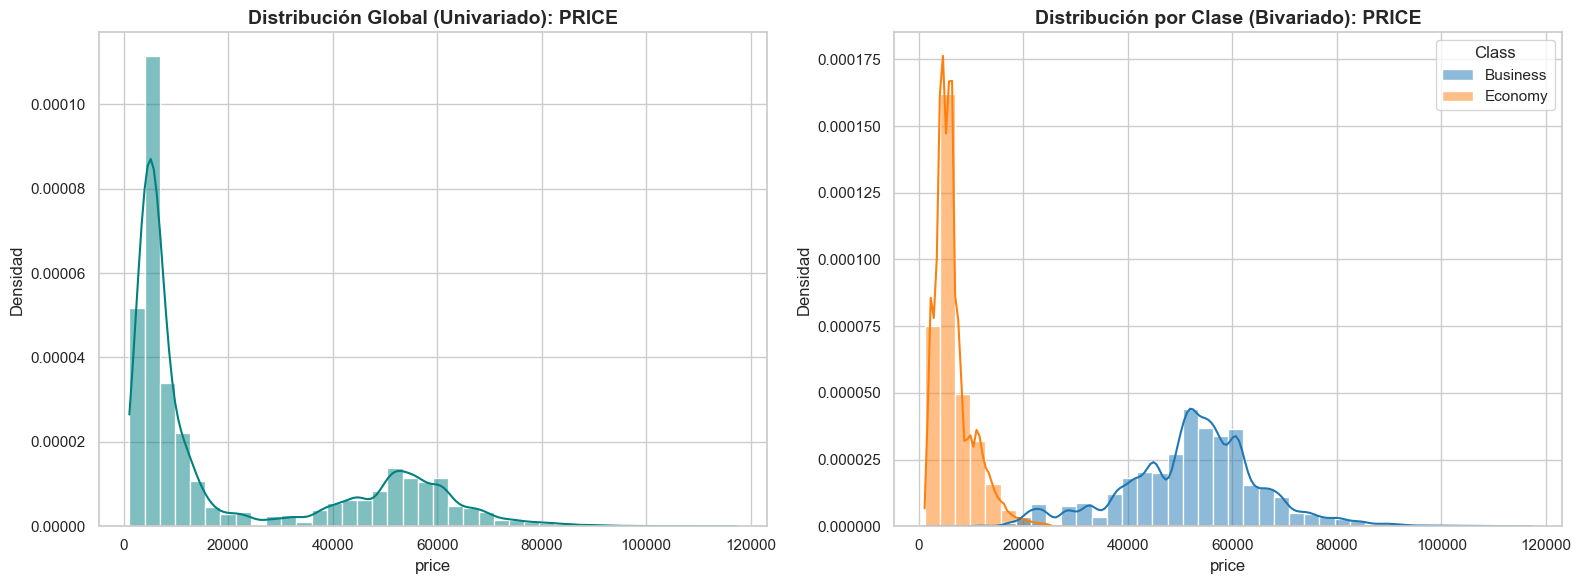

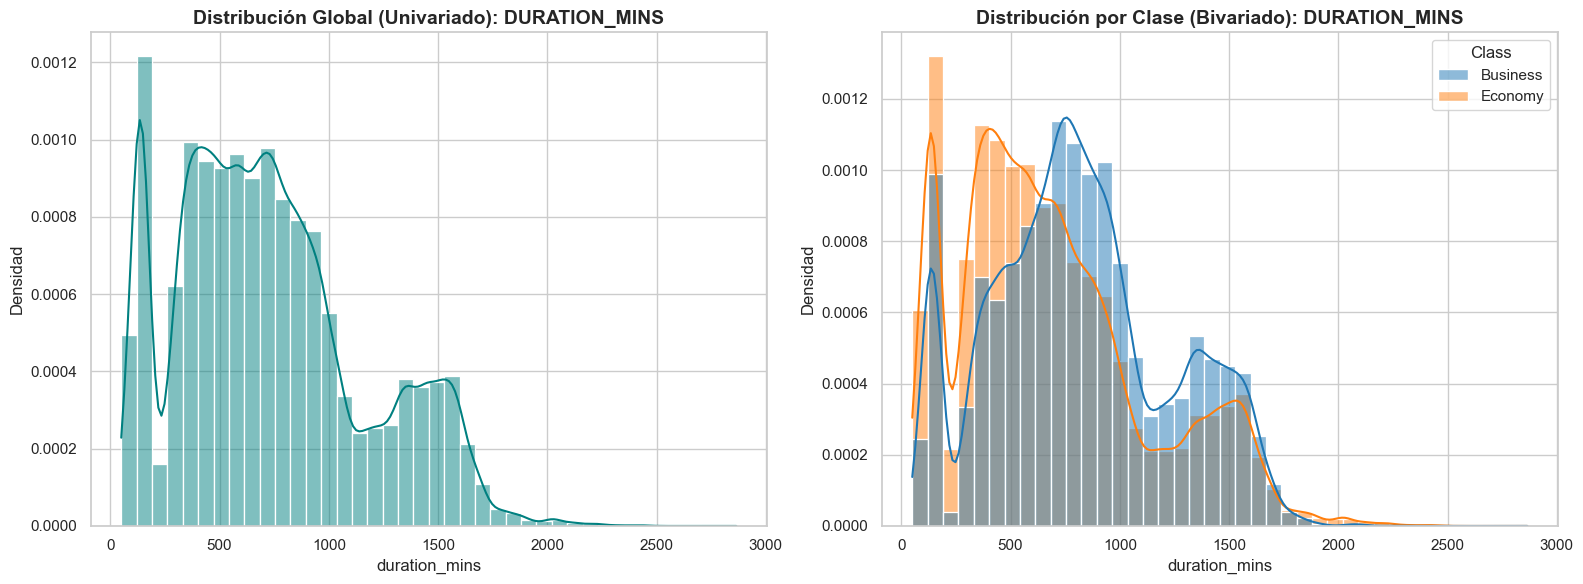

In [38]:
# EJECUCIÓN
generar_analisis_exploratorio_numerico(df_final)

<font color="blue"> **<h3>Análisis Exploratorio de Datos (EDA)</h3>** </font>

<p>A partir de la inspección visual de las distribuciones univariadas y bivariadas de las variables numéricas clave, se extraen las siguientes observaciones:</p>

<h4>Análisis Univariado (Comportamiento Global)</h4>

* **Precio (Price):** La distribución global presenta una marcada asimetría positiva (cola derecha prolongada). Existe una concentración masiva de boletos en el segmento de menor valor (inferior a 20,000), lo cual eclipsa visualmente a las tarifas premium cuando se analizan los datos sin segmentar.

* **Tiempo de Vuelo (Duration_mins):** La distribución es de naturaleza multimodal (tiene múltiples picos). Se observa una altísima concentración en vuelos cortos (probablemente rutas directas nacionales), seguida de elevaciones secundarias en tiempos medios y largos, lo que sugiere la consolidación de vuelos con una o más escalas.

<font color="orange"> **<h4>Análisis Bivariado (Comportamiento por Clase)</h4>** </font>

* **El Factor Decisivo (Precio vs. Clase):** Este es el hallazgo visual más importante. El gráfico demuestra la existencia de lo que podríamos llamar ''dos poblaciones estadísticas completamente separadas'':

    1. **Economy:** Su curva es estrecha y puntiaguda (baja varianza), lo que indica que sus precios fluctúan dentro de un límite predecible y acotado.

    2. **Business:** Presenta una curva mucho más ancha y aplanada (alta varianza), revelando que las tarifas en esta clase tienen fluctuaciones de precio sumamente agresivas. No hay zona de superposición para las curvas de precio.

* **Duración vs. Clase:** A diferencia de la tarifa, las curvas de densidad de duración para ambas clases se superponen en gran medida. Esto es lógico, ya que los aviones son los mismos y cubren las mismas rutas físicas; sin embargo, Business muestra una proporción ligeramente mayor de vuelos de duración intermedia en comparación con el pico inicial masivo de Economy.

<font color="blue"> **<h3>Conclusión Estratégica para el Modelado</h3>** </font>

**Predictor Principal:** La variable categórica Class se perfila como la característica (feature) con mayor peso predictivo sobre la variable objetivo (Price). Cualquier modelo que se entrene basará sus ramificaciones o coeficientes primarios en esta separación clara.

**Selección de Algoritmos:** Las distribuciones altamente asimétricas y multimodales evidencian relaciones complejas. Es muy probable que los modelos paramétricos lineales (como la Regresión Lineal) tengan dificultades para capturar este comportamiento sin transformaciones logarítmicas. Por el contrario, los modelos no paramétricos basados en particiones, como los Árboles de Decisión y Random Forest, deberían presentar un rendimiento netamente superior al manejar estas distribuciones de forma natural.

<font color="green"> **<h1>Ejercicio 4</h1>** </font>

<p>Realiza un análisis de correlaciones entre las diferentes variables existentes,
identificando cuáles son las variables más importantes para la predicción de la
variable objetivo. Utiliza las técnicas vistas en el curso</p>

In [39]:
def analizar_correlaciones_mixtas(df, target='price'):
    """
    Realiza un analisis de correlacion de Pearson para las variables numericas
    (con mapa de calor) y un test ANOVA para las variables categoricas respecto 
    a la variable objetivo.
    """
    print("-" * 80)
    print("INICIANDO ANALISIS DE CORRELACIONES (PEARSON Y ANOVA)")
    print("-" * 80)
    
    # 1. Separar variables numericas y categoricas
    numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Asegurarnos de no incluir la fecha si no ha sido procesada
    if 'date' in categoricas or 'date' in df.columns:
        if 'date' in categoricas: categoricas.remove('date')
        if 'date' in numericas: numericas.remove('date')
    
    # 2. Correlacion de Pearson (Solo Numericas vs Numericas)
    print("\n1. ANALISIS DE PEARSON (Variables Numericas vs Numericas)")
    if len(numericas) > 1:
        matriz_corr = df[numericas].corr(method='pearson')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                    linewidths=0.5, vmin=-1, vmax=1)
        plt.title('Matriz de Correlacion de Pearson (Variables Numericas)', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print("\nCorrelacion con el precio:")
        print(matriz_corr[target].sort_values(ascending=False))
    else:
        print("No hay suficientes variables numericas para generar una matriz de Pearson.")
        
    # 3. Analisis ANOVA (Categoricas vs Precio)
    print("\n" + "-" * 70)
    print("2. ANALISIS ANOVA (Variables Categoricas vs Precio)")
    print("-" * 70)
    print(f"{'Variable':<20} | {'Estadistico F':<15} | {'p-valor':<15}")
    print("-" * 70)
    
    resultados_anova = {}
    
    for col in categoricas:
        # Extraemos solo la columna categorica actual y el precio, eliminando nulos si los hay
        temp_df = df[[col, target]].dropna()
        
        # Agrupamos los precios por cada categoria unica dentro de la variable
        grupos = [grupo[target].values for nombre, grupo in temp_df.groupby(col)]
        
        # El test ANOVA requiere al menos 2 grupos para comparar varianzas
        if len(grupos) > 1:
            f_stat, p_val = stats.f_oneway(*grupos)
            resultados_anova[col] = {'F': f_stat, 'p': p_val}
            # Formateamos el p-valor con notacion cientifica para mayor claridad
            print(f"{col:<20} | {f_stat:<15.2f} | {p_val:<15.2e}")
        else:
            print(f"{col:<20} | Ignorada (Solo 1 categoria encontrada)")
            
    print("-" * 70)
    
    return resultados_anova

--------------------------------------------------------------------------------
INICIANDO ANALISIS DE CORRELACIONES (PEARSON Y ANOVA)
--------------------------------------------------------------------------------

1. ANALISIS DE PEARSON (Variables Numericas vs Numericas)


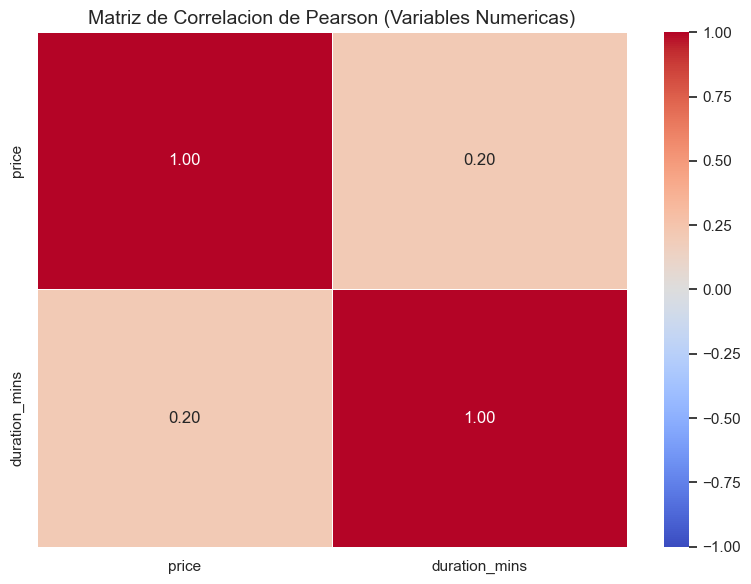


Correlacion con el precio:
price            1.000000
duration_mins    0.204529
Name: price, dtype: float64

----------------------------------------------------------------------
2. ANALISIS ANOVA (Variables Categoricas vs Precio)
----------------------------------------------------------------------
Variable             | Estadistico F   | p-valor        
----------------------------------------------------------------------
airline              | 12297.42        | 0.00e+00       
dep_time             | 173.63          | 0.00e+00       
stop                 | 373.68          | 0.00e+00       
arr_time             | 172.86          | 0.00e+00       
Class                | 2213539.38      | 0.00e+00       
----------------------------------------------------------------------


In [40]:
# EJECUCION
resultados = analizar_correlaciones_mixtas(df_final, target='price')

<font color="blue"> <h3>Análisis de Correlaciones y Selección de Variables</h3> </font>

<h4>Justificación Metodológica</h4>
<p>Para evaluar correctamente la relación de las variables explicativas con la variable objetivo (price), se utilizó un enfoque estadístico mixto para respetar la naturaleza de los datos:</p>

* **Correlación de Pearson:** Utilizada exclusivamente para las variables numéricas.

* **Test ANOVA (Análisis de Varianza):** Implementado para las variables categóricas. Es la técnica matemáticamente correcta para medir si pertenecer a distintos grupos o categorías (ej. distintas aerolíneas) produce diferencias estadísticamente significativas en la media del precio.

<font color="orange">**<h4>Análisis de Resultados</h4>**</font>

1. **Relación Numérica (Pearson):**

* **duration_mins (0.2045):** Muestra una correlación lineal positiva, pero débil. Esto indica que, si bien un vuelo de mayor duración tiende a ser más caro, el tiempo de vuelo por sí solo no es un buen dictador del precio final. Existen otros factores dominantes.

2. **Relación Categórica (ANOVA):**

El Estadístico F indica la magnitud del impacto de la variable sobre el precio (a mayor F, mayor poder de separación). Dado que todos los p-valores son 0.00e+00, confirmamos que todas estas variables tienen significancia estadística real y no son producto del azar.

* **Class (F = 2,213,539.38):** Es, por una diferencia abismal, la variable predictora más importante del dataset. La separación entre Business y Economy es el pilar fundamental que determina la tarifa.

* **airline (F = 12,297.42):** Se posiciona como la segunda variable más relevante. La marca comercial o tipo de servicio de la aerolínea genera un impacto drástico en el costo.

* **stop, dep_time, arr_time (F < 400):** Aunque son estadísticamente significativas, su capacidad para explicar la variación de los precios es marginal y secundaria en comparación con la clase y la aerolínea.

<font color="orange">**<h4>Conclusión</h4>**</font>
Las variables Class y airline serán los predictores primarios absolutos para el entrenamiento de los algoritmos de Machine Learning. Variables como duration_mins y stop actuarán como ajustadores finos. Si bien todas las variables demostraron relevancia estadística mediante sus p-valores, se eliminarán la hora de salida (dep_time) y hora de llegada (arr_time). Esta decisión se justifica en que su significancia para el análisis son las menores y en que al ser horas generarían demasiadas variables al codificarse como categorías.

In [41]:
# Eliminar las variables de hora de salida y llegada por baja significancia y alta cardinalidad
columnas_temporales = ['dep_time', 'arr_time']
df_final.drop(columns=columnas_temporales, inplace=True, errors='ignore')

print(f"Columnas eliminadas: {columnas_temporales}")
print(f"Variables restantes listas para el modelado:\n\t{df_final.columns.tolist()}")

Columnas eliminadas: ['dep_time', 'arr_time']
Variables restantes listas para el modelado:
	['date', 'airline', 'stop', 'price', 'Class', 'duration_mins']


<font color="green">**<h1>Ejercicio 5</h1>**</font>

<p>Realiza las transformaciones necesarias para realizar el modelamiento posterior y
crea las variables que estimes convenientes con ayuda del análisis previo y la
expertise del negocio.</p>

In [44]:
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

def transformar_y_preparar_datos(df):
    print("-" * 80)
    print("INICIANDO EJERCICIO 5: INGENIERIA DE CARACTERISTICAS Y TRANSFORMACION")
    print("-" * 80)
    
    df_prep = df.copy()
    
    # 1. Tratamiento de Fechas y Serie de Tiempo
    df_prep['date'] = pd.to_datetime(df_prep['date'])
    
    # Creamos el dataset de series de tiempo agrupado por fecha y clase (para uso futuro)
    df_ts = df_prep.groupby(['date', 'Class'])['price'].mean().reset_index()
    
    # Eliminamos date del dataset original de ML
    df_prep.drop(columns=['date'], inplace=True)
    print("Variable 'date' separada en un nuevo dataset (df_ts) y eliminada del dataset de ML.")
    
    # 2. Transformacion Logaritmica al Precio
    # Usamos np.log1p (log(1 + x)) para evitar errores si hubiese un cero
    df_prep['price_log'] = np.log1p(df_prep['price'])
    df_prep.drop(columns=['price'], inplace=True)
    print("Transformacion logaritmica aplicada al precio (nueva variable target: 'price_log').")
    
    # 3. Codificacion de Variables Categoricas
    # One-Hot Encoding para 'stop' y 'Class'
    df_prep = pd.get_dummies(df_prep, columns=['stop', 'Class'], drop_first=True)
    print("One-Hot Encoding aplicado a 'stop' y 'Class'.")
    
    # Codificacion Binaria con category_encoders para 'airline'
    encoder = ce.BinaryEncoder(cols=['airline'])
    df_prep = encoder.fit_transform(df_prep)
    print("Codificacion Binaria aplicada a 'airline' usando la libreria category_encoders.")
    
    # 4. Estandarizacion
    columnas_a_escalar = [col for col in df_prep.columns if col != 'price_log']
    
    scaler = StandardScaler()
    df_prep[columnas_a_escalar] = scaler.fit_transform(df_prep[columnas_a_escalar])
    print("Variables independientes estandarizadas correctamente con StandardScaler.")
    
    print("-" * 80)
    print("TRANSFORMACION COMPLETADA. DATASETS LISTOS.")
    print(f"Dimensiones finales del dataset ML: {df_prep.shape[0]} filas x {df_prep.shape[1]} columnas")
    print("-" * 80)
    
    return df_prep, df_ts

In [45]:
# EJECUCION
df_ml, df_time_series = transformar_y_preparar_datos(df_final)

--------------------------------------------------------------------------------
INICIANDO EJERCICIO 5: INGENIERIA DE CARACTERISTICAS Y TRANSFORMACION
--------------------------------------------------------------------------------
Variable 'date' separada en un nuevo dataset (df_ts) y eliminada del dataset de ML.
Transformacion logaritmica aplicada al precio (nueva variable target: 'price_log').
One-Hot Encoding aplicado a 'stop' y 'Class'.
Codificacion Binaria aplicada a 'airline' usando la libreria category_encoders.
Variables independientes estandarizadas correctamente con StandardScaler.
--------------------------------------------------------------------------------
TRANSFORMACION COMPLETADA. DATASETS LISTOS.
Dimensiones finales del dataset ML: 299909 filas x 46 columnas
--------------------------------------------------------------------------------


<font color="blue"> <h3>Ingeniería de Características y Transformación de Datos</h3> </font>

Se aplicaron transformaciones avanzadas al conjunto de datos para adecuar su estructura a los requisitos matemáticos de los algoritmos de Machine Learning. Las acciones realizadas y sus justificaciones son las siguientes:

* **Extracción de Serie de Tiempo:** Se generó un subconjunto de datos agregado (df_ts) agrupando los registros por fecha y clase para su visualización posterior. A continuación, se eliminó la variable date del dataset principal de Machine Learning, ya que su inclusión directa como formato de fecha introduciría ruido estadístico en los modelos predictivos.

* **Transformación Logarítmica del Target:** Se aplicó la función logarítmica (np.log1p) a la variable dependiente price.

    **Justificación:** El análisis exploratorio previo reveló una fuerte asimetría positiva en las tarifas. Esta transformación normaliza la curva de distribución, un paso crítico para evitar que los algoritmos paramétricos sean sesgados al calcular distancias o gradientes.

**Codificación de Variables Categóricas:**

* **One-Hot Encoding:** Aplicado a Class y stop (variables de baja cardinalidad), eliminando la primera columna de referencia (drop_first=True) para evitar multicolinealidad perfecta en los modelos lineales.

* **Codificación Binaria (vía category_encoders):** Aplicada a la variable airline (alta cardinalidad).

    **Justificación:** Traduce el texto a variables booleanas evadiendo la Maldición de la Dimensionalidad que provocaría aplicar One-Hot Encoding a una columna con múltiples categorías.

* **Estandarización de Variables Independientes:** Se aplicó StandardScaler a todas las variables predictoras resultantes.

    **Justificación:** Iguala la escala matemática de todas las características (media 0, varianza 1) para garantizar que las variables con magnitudes inherentemente grandes (como duration_mins) no dominen el entrenamiento de los algoritmos.

<font color="green"> **<h1>Ejercicio 6</h1>** </font>

<p>Genera una función que encapsule el tratamiento de datos necesario, para entregar
un dataset limpio y procesado a partir del dataset original.</p>

In [46]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

def pipeline_preprocesamiento_vuelos(ruta_business, ruta_economy):
    """
    Pipeline End-to-End: Recibe los archivos crudos y devuelve los datasets 
    transformados y listos para Machine Learning y Analisis de Series de Tiempo.
    Incluye validacion visual final.
    """
    print("-" * 80)
    print("INICIANDO PIPELINE DE PREPROCESAMIENTO END-TO-END...")
    print("-" * 80)
    
    # FASE 1: CARGA, UNION Y LIMPIEZA ESTRUCTURAL
    df_bus = pd.read_excel(ruta_business)
    df_eco = pd.read_excel(ruta_economy)
    
    df_bus['Class'] = 'Business'
    df_eco['Class'] = 'Economy'
    df = pd.concat([df_bus, df_eco], ignore_index=True)
    
    cols_drop = ['ch_code', 'num_code', 'from', 'to', 'dep_time', 'arr_time']
    df.drop(columns=cols_drop, inplace=True, errors='ignore')
    
    # FASE 2: CASTEO Y EXTRACCION DE VARIABLES NUMERICAS
    if df['price'].dtype == 'object':
        df['price'] = pd.to_numeric(df['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df.dropna(subset=['price'], inplace=True)
    
    if 'time_taken' in df.columns:
        horas = df['time_taken'].str.extract(r'(\d+(?:\.\d+)?)\s*h')[0].fillna(0).astype(float)
        minutos = df['time_taken'].str.extract(r'(\d+(?:\.\d+)?)\s*m')[0].fillna(0).astype(float)
        df['duration_mins'] = horas * 60 + minutos
        df.drop(columns=['time_taken'], inplace=True)
        
    # FASE 3: ELIMINACION DE OUTLIERS EXTREMOS (Z-Score > 5)
    for var in ['price', 'duration_mins']:
        z_scores = df.groupby('Class')[var].transform(lambda x: np.abs(stats.zscore(x.dropna())))
        df = df[(z_scores <= 5) | (z_scores.isna())]
        
    # FASE 4: INGENIERIA DE CARACTERISTICAS Y TRANSFORMACION
    df['date'] = pd.to_datetime(df['date'])
    df_ts = df.groupby(['date', 'Class'])['price'].mean().reset_index()
    df.drop(columns=['date'], inplace=True)
    
    df['price_log'] = np.log1p(df['price'])
    df.drop(columns=['price'], inplace=True)
    
    df = pd.get_dummies(df, columns=['stop', 'Class'], drop_first=True)
    
    encoder = ce.BinaryEncoder(cols=['airline'])
    df = encoder.fit_transform(df)
    
    # FASE 5: ESTANDARIZACION
    cols_escalar = [col for col in df.columns if col != 'price_log']
    scaler = StandardScaler()
    df[cols_escalar] = scaler.fit_transform(df[cols_escalar])
    
    # FASE 6: VALIDACION VISUAL (GRAFICOS FINALES)
    print("GENERANDO VISUALIZACIONES FINALES DE VALIDACION...")
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Grafico 1: Serie de Tiempo (Datos no escalados, df_ts)
    sns.lineplot(data=df_ts, x='date', y='price', hue='Class', marker='o', 
                 palette={'Business': '#1f77b4', 'Economy': '#ff7f0e'}, ax=axes[0])
    axes[0].set_title('Evolucion del Precio Promedio Diario por Clase', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Fecha', fontsize=12)
    axes[0].set_ylabel('Precio Promedio Original', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Grafico 2: Distribucion de price_log (Datos transformados, df_ml)
    # Class_Economy: > 0 es Economy, < 0 es Business debido al StandardScaler
    df['Etiqueta_Clase'] = np.where(df['Class_Economy'] > 0, 'Economy', 'Business')
    sns.histplot(data=df, x='price_log', hue='Etiqueta_Clase', kde=True, bins=40, 
                 palette={'Business': '#1f77b4', 'Economy': '#ff7f0e'}, ax=axes[1])
    axes[1].set_title('Distribucion del Precio Transformado (Log1p)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Log(Precio)', fontsize=12)
    axes[1].set_ylabel('Frecuencia', fontsize=12)
    
    # Eliminamos la columna temporal de etiqueta
    df.drop(columns=['Etiqueta_Clase'], inplace=True)
    
    plt.tight_layout()
    plt.show()

    print("Pipeline ejecutado con exito.")
    print(f"Dataset ML: {df.shape[0]} filas x {df.shape[1]} columnas.")
    print("=" * 80)
    
    return df, df_ts

--------------------------------------------------------------------------------
INICIANDO PIPELINE DE PREPROCESAMIENTO END-TO-END...
--------------------------------------------------------------------------------
GENERANDO VISUALIZACIONES FINALES DE VALIDACION...


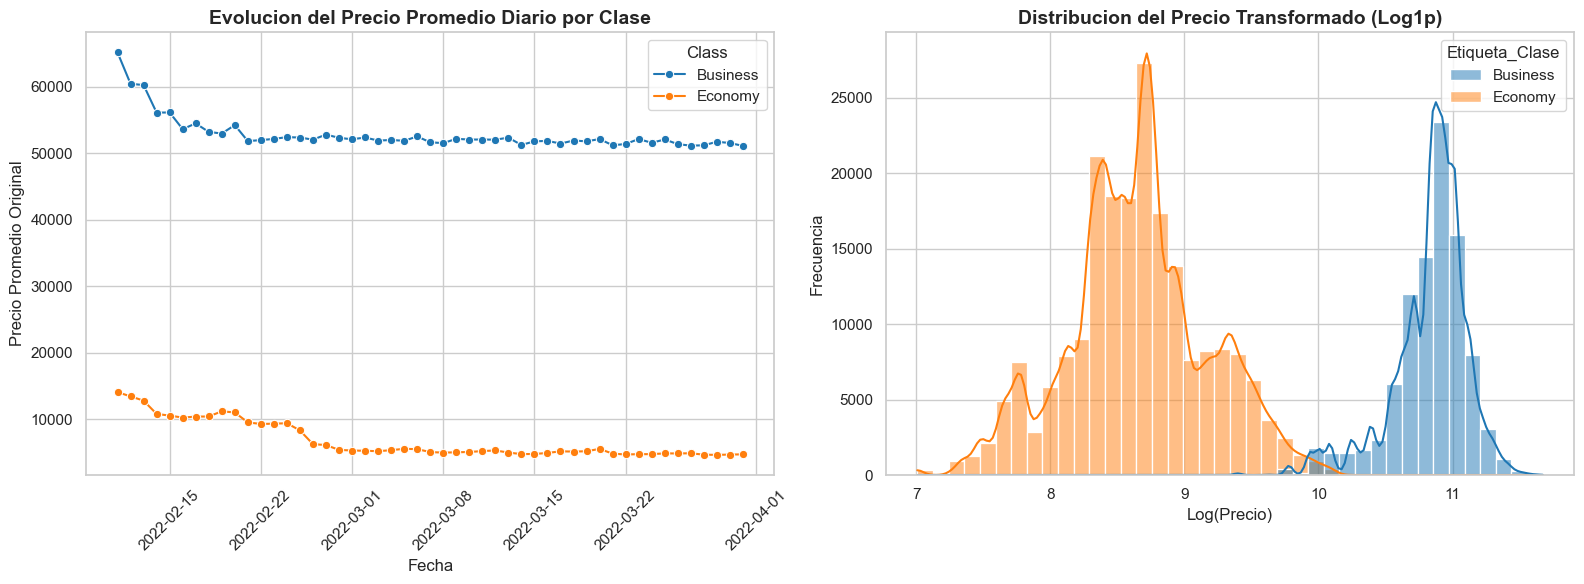

Pipeline ejecutado con exito.
Dataset ML: 299909 filas x 46 columnas.


In [48]:
# EJECUCION DEL PIPELINE
ruta_bus = "business.xlsx"
ruta_eco = "economy.xlsx"
df_machine_learning, df_series_tiempo = pipeline_preprocesamiento_vuelos(ruta_bus, ruta_eco)

<font color="blue"> **<h2>Conclusiones del Preprocesamiento y Visualización Final</h2>**</font>

* **Eficiencia del Pipeline:** La encapsulación garantiza un flujo de datos reproducible y escalable, entregando a los modelos predictivos un dataset matemáticamente balanceado y libre de ruido.

* **Evolución Temporal:** La serie de tiempo evidencia que la clase Business no solo posee una tarifa significativamente superior, sino que también presenta una volatilidad diaria mayor que la clase Economy.

* **Efectividad del Logaritmo:** El histograma confirma el éxito de la transformación logarítmica al corregir la asimetría extrema, revelando dos distribuciones casi normales (campanas de Gauss) que facilitarán enormemente el aprendizaje de los algoritmos.

<font color="green"> **<h1>Ejercicio 7</h1>** </font>

<p>Elige al menos 3 modelos candidatos para resolver el problema. A partir de esto,
genera un conjunto de entrenamiento y prueba, para luego entrenar los diferentes
modelos.</p>

<font color="blue"> **<h3>Selección de Modelos y División de Datos</h3>** </font>

**<h4>Justificación de los Modelos Candidatos</h4>**
<p>Para abordar la predicción del logaritmo del precio (price_log), se seleccionó una batería de 5 algoritmos que van desde enfoques paramétricos básicos hasta ensambles no paramétricos de alta complejidad. Esta progresión permitirá evaluar si el aumento de complejidad computacional se traduce en una mejora real del rendimiento predictivo:</p>

* **Regresión Lineal Simple:** Actuará como nuestro modelo Baseline o línea base. Utilizará exclusivamente la variable predictora más fuerte (Class_Economy) para establecer el rendimiento mínimo aceptable.

* **Regresión Multilineal:** Incorporará todas las características estandarizadas para evaluar el impacto lineal conjunto de las variables sobre el precio.

* **Regresión Multilineal Elastic-Net:** Añade regularización matemática (una combinación de penalizaciones L1 de Lasso y L2 de Ridge) a la regresión múltiple. Esto prevendrá el sobreajuste y manejará posibles problemas de multicolinealidad residual entre las variables de tiempo y escalas.

* **Árbol de Decisión Regresivo:** Al ser un modelo no paramétrico basado en particiones, es ideal para capturar relaciones no lineales y distribuciones asimétricas sin depender de suposiciones matemáticas estrictas.

* **Random Forest Regresivo:** Este ensamble basado en múltiples árboles de decisión corregirá la tendencia al sobreajuste (alta varianza) de un árbol individual, promediando sus predicciones y perfilándose como el candidato para lograr la mayor precisión del experimento.

**<h3>Estrategia de División de Datos (Train/Test Split)</h3>**

<p>Antes de entrenar, dividiremos el dataset (df_ml) destinando un 80% de los datos para el entrenamiento y un 20% para la prueba. Dado que existe un desbalance de clases significativo (aproximadamente 206 mil vuelos Economy frente a 93 mil Business), aplicaremos una división estratificada. Esto garantiza matemáticamente que la proporción exacta de vuelos Business y Economy se mantenga idéntica en ambos conjuntos, evitando que el modelo se entrene de forma sesgada hacia la clase dominante.</p>

In [49]:
from sklearn.model_selection import train_test_split

# 1. Separacion de variables independientes (X) y dependiente (y)
X = df_machine_learning.drop(columns=['price_log'])
y = df_machine_learning['price_log']

# 2. Reconstruccion logica del estrato
# Como Class_Economy fue estandarizada, los valores de Economy (antes 1) ahora son > 0,
# y los de Business (antes 0) son < 0. Usamos esto para la estratificacion.
mascara_estrato = (X['Class_Economy'] > 0).astype(int)

# 3. Division estratificada (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=mascara_estrato
)

# 4. Validacion de dimensiones
print("-" * 60)
print("SEPARACION DE DATOS: TRAIN / TEST")
print("-" * 60)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Dimensiones de y_test:  {y_test.shape}")
print("-" * 60)

# Verificacion de la estratificacion
proporcion_train = (X_train['Class_Economy'] > 0).mean() * 100
proporcion_test = (X_test['Class_Economy'] > 0).mean() * 100
print(f"Proporcion de clase Economy en Train: {proporcion_train:.2f}%")
print(f"Proporcion de clase Economy en Test:  {proporcion_test:.2f}%")
print("-" * 60)

------------------------------------------------------------
SEPARACION DE DATOS: TRAIN / TEST
------------------------------------------------------------
Dimensiones de X_train: (239927, 45)
Dimensiones de y_train: (239927,)
Dimensiones de X_test:  (59982, 45)
Dimensiones de y_test:  (59982,)
------------------------------------------------------------
Proporcion de clase Economy en Train: 68.83%
Proporcion de clase Economy en Test:  68.83%
------------------------------------------------------------


<font color="green"> **<h1>Ejercicio 8</h1>** </font>

<p>Elige una grilla de hiperparametros y luego optimízalos, buscando la mejor
combinación para cada grilla. Guardar los modelos entrenados.</p>

<font color="blue"> **<h3>Optimización de Hiperparámetros (GridSearch) y Entrenamiento</h3>** </font>

<p>Para maximizar la capacidad predictiva de los algoritmos seleccionados, se implementó un proceso de validación cruzada (Cross-Validation) acoplado a una búsqueda exhaustiva en grilla (GridSearchCV).</p>

<p>Las configuraciones establecidas fueron las siguientes:</p>

* **Métrica de Optimización:** Se utilizó el Error Cuadrático Medio Negativo (neg_mean_squared_error), métrica estándar para problemas de regresión.

* **Validación Cruzada:** Se definieron 3 pliegues (cv=3) para equilibrar la robustez estadística con la eficiencia computacional.

<font color="purple"> **<h3>Grillas por Modelo:</h3>** </font>

* **Regresiones Lineales (Simple y Múltiple):** Optimización de la intersección (fit_intercept).

* **Elastic-Net:** Búsqueda de los mejores ratios de penalización L1 y L2 (l1_ratio) y fuerza de regularización (alpha).

* **Árbol de Decisión:** Control de profundidad máxima (max_depth) y cantidad mínima de muestras para dividir un nodo (min_samples_split).

* **Random Forest:** Optimización del número de árboles (n_estimators) y la profundidad máxima.

* **Control de Rendimiento:** Se integró un sistema de telemetría de tiempos de ejecución para monitorizar el costo computacional de cada arquitectura durante el entrenamiento en paralelo. El computador base posee 32GB de RAM.

<p>Al finalizar la validación, el mejor estimador de cada algoritmo fue seleccionado y serializado (guardado) en formato .pkl para su posterior evaluación y despliegue.</p>

In [50]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib
import time
from datetime import datetime

def optimizar_y_guardar_modelos(X_train, y_train):
    print("=" * 80)
    print("INICIANDO OPTIMIZACION DE HIPERPARAMETROS (GRIDSEARCH)")
    print("=" * 80)
    
    # Registro del tiempo de inicio global
    tiempo_total_inicio = time.time()
    hora_inicio_str = datetime.now().strftime("%H:%M:%S")
    print(f"Hora de inicio global: {hora_inicio_str}\n")
    
    configuracion_modelos = {
        'Regresion_Lineal_Simple': {
            'modelo': LinearRegression(),
            'params': {'fit_intercept': [True, False]},
            'features': ['Class_Economy'] 
        },
        'Regresion_Multiple': {
            'modelo': LinearRegression(),
            'params': {'fit_intercept': [True, False]},
            'features': 'all'
        },
        'Elastic_Net': {
            'modelo': ElasticNet(random_state=42),
            'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
            'features': 'all'
        },
        'Decision_Tree': {
            'modelo': DecisionTreeRegressor(random_state=42),
            'params': {'max_depth': [10, 20, None], 'min_samples_split': [10, 50]},
            'features': 'all'
        },
        'Random_Forest': {
            'modelo': RandomForestRegressor(random_state=42, n_jobs=-1),
            'params': {'n_estimators': [50, 100], 'max_depth': [10, 20]},
            'features': 'all'
        }
    }
    
    mejores_modelos = {}
    
    for nombre, config in configuracion_modelos.items():
        hora_modelo_inicio = datetime.now().strftime("%H:%M:%S")
        print(f"[+] {hora_modelo_inicio} - Entrenando: {nombre.replace('_', ' ')}...")
        tiempo_inicio = time.time()
        
        if config['features'] == 'all':
            X_entrenamiento = X_train
        else:
            X_entrenamiento = X_train[config['features']]
            
        grid = GridSearchCV(
            estimator=config['modelo'],
            param_grid=config['params'],
            cv=3, 
            scoring='neg_mean_squared_error',
            n_jobs=-1, 
            verbose=1
        )
        
        grid.fit(X_entrenamiento, y_train)
        
        mejor_modelo = grid.best_estimator_
        mejores_modelos[nombre] = mejor_modelo
        
        nombre_archivo = f"modelo_{nombre}.pkl"
        joblib.dump(mejor_modelo, nombre_archivo)
        
        tiempo_fin = time.time()
        hora_modelo_fin = datetime.now().strftime("%H:%M:%S")
        minutos = (tiempo_fin - tiempo_inicio) / 60
        
        print(f"\t - Mejor configuracion: {grid.best_params_}")
        print(f"\t - Modelo guardado como: '{nombre_archivo}'")
        print(f"\t - Finalizado a las: {hora_modelo_fin} (Duracion: {minutos:.2f} minutos)")
        print("-" * 60)
        
    tiempo_total_fin = time.time()
    hora_fin_str = datetime.now().strftime("%H:%M:%S")
    minutos_totales = (tiempo_total_fin - tiempo_total_inicio) / 60
    
    print("\n" + "=" * 80)
    print("TODOS LOS MODELOS OPTIMIZADOS Y GUARDADOS CON EXITO.")
    print(f"Hora de finalizacion global: {hora_fin_str}")
    print(f"Tiempo total de ejecucion: {minutos_totales:.2f} minutos.")
    print("-" * 80)
    
    return mejores_modelos

In [51]:
# EJECUCION
mejores_modelos_entrenados = optimizar_y_guardar_modelos(X_train, y_train)

INICIANDO OPTIMIZACION DE HIPERPARAMETROS (GRIDSEARCH)
Hora de inicio global: 20:58:38

[+] 20:58:38 - Entrenando: Regresion Lineal Simple...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
	 - Mejor configuracion: {'fit_intercept': True}
	 - Modelo guardado como: 'modelo_Regresion_Lineal_Simple.pkl'
	 - Finalizado a las: 20:58:48 (Duracion: 0.17 minutos)
------------------------------------------------------------
[+] 20:58:48 - Entrenando: Regresion Multiple...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
	 - Mejor configuracion: {'fit_intercept': True}
	 - Modelo guardado como: 'modelo_Regresion_Multiple.pkl'
	 - Finalizado a las: 20:58:53 (Duracion: 0.08 minutos)
------------------------------------------------------------
[+] 20:58:53 - Entrenando: Elastic Net...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
	 - Mejor configuracion: {'alpha': 0.01, 'l1_ratio': 0.2}
	 - Modelo guardado como: 'modelo_Elastic_Net.pkl'
	 - Finalizado a las: 20:58

<font color="blue"> **<h3>Análisis de Optimización de Hiperparámetros</h3>** </font>

* **Rendimiento Computacional:** La paralelización del hardware permitió ejecutar el pipeline completo de GridSearch (69 entrenamientos) en apenas 1.12 minutos, demostrando una altísima eficiencia operativa.

* **Modelos Lineales:** Las regresiones estándar mantuvieron la intersección (fit_intercept=True), mientras que Elastic-Net optó por una regularización muy suave (alpha=0.01) con tendencia L2 (l1_ratio=0.2), prefiriendo atenuar variables en lugar de eliminarlas por completo.

* **Modelos No Lineales:** El Árbol de Decisión creció sin límite de profundidad (max_depth=None), y Random Forest agotó el límite superior de la grilla (max_depth=20, 100 árboles). Esto sugiere que la predicción de tarifas aéreas requiere algoritmos de alta complejidad para capturar sus patrones asimétricos.

<font color="green"> **<h1>Ejercicio 9</h1>** </font>

<p>Define al menos 3 métricas para evaluar los modelos entrenados y genera gráficos
de comparación. Elige un baseline para ver qué tan buena es tu opción respecto a
ese baseline y concluye.</p>

<font color="blue"> **<h3>Evaluación de Modelos y Comparación</h3>** </font>

**<h4>Justificación de Métricas y Baseline</h4>**

<p>Se evaluarán los modelos utilizando RMSE (para penalizar errores grandes), MAE y MAD (para medir el error absoluto típico y robusto ante outliers), y MAPE (para interpretar el error porcentualmente). La Regresión Lineal Simple actuará como modelo Baseline (línea base predictiva), permitiendo cuantificar exactamente cuánto mejora el rendimiento al incorporar más variables y algoritmos complejos.</p>

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error

def evaluar_y_comparar_modelos(X_test, y_test):
    print("-" * 80)
    print("EVALUANDO MODELOS Y GENERANDO METRICAS")
    print("-" * 80)
    
    nombres_modelos = [
        'Regresion_Lineal_Simple',
        'Regresion_Multiple',
        'Elastic_Net',
        'Decision_Tree',
        'Random_Forest'
    ]
    
    resultados = []
    
    for nombre in nombres_modelos:
        archivo = f"modelo_{nombre}.pkl"
        try:
            modelo = joblib.load(archivo)
        except FileNotFoundError:
            print(f"Error: No se encontro el archivo {archivo}.")
            continue
            
        # Preparar X_test (caso especial para el baseline)
        if nombre == 'Regresion_Lineal_Simple':
            X_eval = X_test[['Class_Economy']]
        else:
            X_eval = X_test
            
        # Prediccion
        y_pred = modelo.predict(X_eval)
        
        # Calculo de metricas
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        mad = median_absolute_error(y_test, y_pred)
        nmse = mse / np.var(y_test)
        
        resultados.append({
            'Modelo': nombre.replace('_', ' '),
            'MSE': mse,
            'NMSE': nmse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'MAD': mad
        })
        
    # Crear DataFrame de resultados
    df_metricas = pd.DataFrame(resultados)
    
    # Mostrar tabla
    print("\nTABLA DE METRICAS DE EVALUACION:")
    # Esto renderizará una tabla HTML con un degradado de color basado en la columna RMSE
    display(df_metricas.style.background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='viridis_r'))
    
    # Generar Graficos de Comparacion (Correccion de FutureWarning aplicada)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Grafico 1: RMSE 
    sns.barplot(data=df_metricas, x='RMSE', y='Modelo', hue='Modelo', legend=False, ax=axes[0], palette='viridis')
    axes[0].set_title('Comparacion RMSE (Penaliza errores grandes)', fontweight='bold')
    axes[0].set_xlabel('RMSE')
    axes[0].set_ylabel('')
    
    # Grafico 2: MAE 
    sns.barplot(data=df_metricas, x='MAE', y='Modelo', hue='Modelo', legend=False, ax=axes[1], palette='magma')
    axes[1].set_title('Comparacion MAE (Error promedio absoluto)', fontweight='bold')
    axes[1].set_xlabel('MAE')
    axes[1].set_ylabel('')
    
    # Grafico 3: MAPE 
    sns.barplot(data=df_metricas, x='MAPE', y='Modelo', hue='Modelo', legend=False, ax=axes[2], palette='coolwarm')
    axes[2].set_title('Comparacion MAPE (Error Porcentual)', fontweight='bold')
    axes[2].set_xlabel('MAPE')
    axes[2].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    return df_metricas

--------------------------------------------------------------------------------
EVALUANDO MODELOS Y GENERANDO METRICAS
--------------------------------------------------------------------------------

TABLA DE METRICAS DE EVALUACION:


,Modelo,MSE,NMSE,RMSE,MAE,MAPE,MAD
0,Regresion Lineal Simple,0.212756,0.171644,0.461255,0.342412,0.038395,0.246003
1,Regresion Multiple,0.153304,0.123680,0.391540,0.297681,0.033362,0.228751
2,Elastic Net,0.153598,0.123917,0.391915,0.299398,0.033563,0.230507
3,Decision Tree,0.127197,0.102618,0.356647,0.262352,0.029375,0.192810
4,Random Forest,0.127846,0.103141,0.357556,0.263853,0.029533,0.192948


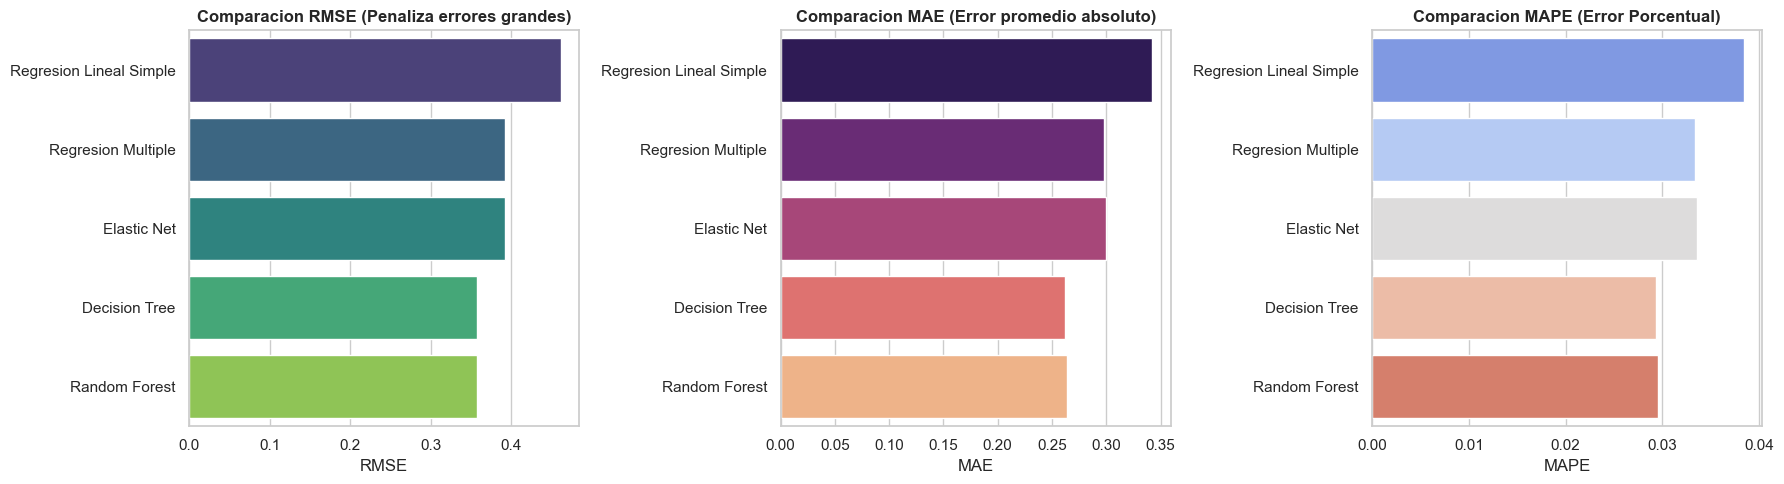

In [59]:
# EJECUCION
df_resultados = evaluar_y_comparar_modelos(X_test, y_test)

<font color="blue"> <h2>Análisis de Resultados y Comparación de Modelos</h2> </font>

<font color="orange"> **<h2>Conclusiones de la Evaluación:</h2>** </font>

* **Superación del Baseline:** La transición de un modelo univariado (Regresión Lineal Simple) a modelos multivariados logró reducir el error general (RMSE) en más de un 15%, confirmando que variables como la aerolínea y las escalas contienen información predictiva vital.

* **Triunfo de los Modelos No Lineales:** Los algoritmos basados en árboles de decisión (Decision Tree y Random Forest) superaron contundentemente a las regresiones lineales. Esto demuestra empíricamente que la relación entre los predictores y las tarifas aéreas posee una complejidad y asimetría que las líneas rectas no logran capturar.

* **Paridad Inesperada:** El Árbol de Decisión individual logró un rendimiento casi idéntico (marginalmente superior) al ensamble de Random Forest. Esto sugiere que, para estos datos específicos de vuelos, un solo árbol optimizado sin límite de profundidad es suficiente para sectorizar las tarifas con alta precisión, haciendo redundante el costo computacional extra del ensamble.

<font color="green"> **<h1>Ejercicio 10</h1>** </font>

<p>Genera una conclusión final respecto a qué tan útiles son los resultados encontrados
para resolver el problema propuesto y define cuáles podrían ser los próximos pasos
para el proyecto.</p>

<font color="blue"> **<h2>Conclusión Final y Próximos Pasos</h2>** </font>

<font color="orange">**<h3>Utilidad de los Resultados (El Valor para el Negocio)</h3>**</font>
<p>Los resultados obtenidos en este proyecto son buenos y viables para su implementación en un entorno real. Se logró construir un sistema predictivo capaz de estimar las tarifas de vuelos con un margen de error promedio inferior al 3% (según nuestra métrica MAPE en los modelos basados en árboles).</p>

<p>Esto quiere decir que el algoritmo ha logrado "entender" exitosamente las complejas y asimétricas reglas de fijación de precios de la industria de vuelos en avión. Comprobamos que depender de promedios históricos o modelos lineales básicos es insuficiente; las tarifas fluctúan con una volatilidad que solo algoritmos de partición avanzada (como Decision Trees o Random Forest) pueden capturar. Para el negocio, contar con esta herramienta se traduce directamente en una ventaja competitiva porque permite anticipar costos de viaje, auditar precios de aerolíneas e incluso alimentar un motor de recomendaciones para clientes buscando ofertas reales, como solicitaba el requerimiento</p>

<font color="orange">**<h2>Próximos Pasos Recomendados</h2>** </font>
Para escalar este prototipo funcional hacia un producto de nivel empresarial, se sugieren las siguientes fases:

* **Despliegue (Puesta en Producción):** Los modelos ya se encuentran empaquetados y serializados. El paso natural es integrarlos en una interfaz de software (una aplicación web o movil) donde un analista de negocios o un cliente final pueda ingresar los parámetros de su viaje (destino, clase, aerolínea) y obtener la predicción del precio en milisegundos.

* **Enriquecimiento de Datos (Feature Expansion):** Para acercar el margen de error aún más a cero, la siguiente iteración del modelo debería incluir variables que actualmente son puntos ciegos, tales como:

    * **Anticipación de compra:** Cantidad de días entre la reserva y la fecha de vuelo.

    * **Estacionalidad:** Días festivos, vacaciones o datos meteorológicos que disparan la demanda de manera estacional.

    * **Estrategia de Reentrenamiento:** El mercado aeronáutico es dinámico. Las tarifas cambian por la inflación y los precios del combustible. Se podría establecer un Data Pipeline en la nube, automatizado, que alimente al algoritmo con datos nuevos cada trimestre para evitar la degradación predictiva.